# **Equazioni non lineari**

Si consideri il problema della ricerca degli zeri dell'equazione non
lineare $f(x)=0$, dove $f$ è definita da:
\begin{equation}
f(x):=e^{x}-x^{2}-\textrm{sin}(x)-1,\qquad x\in[-2,2]\;.
\end{equation}

# **Rappresentazione grafica della funzione**          
Disegnare il grafico della funzione $f$ e la retta $y=0$ in modo da evidenziare le due soluzioni dell'equazione.

In [11]:
# step 0 -> ricordarsi di importare i pacchetti numpy and matplotlib

import numpy as np
import matplotlib.pyplot as plt

Vediamo un nuovo costrutto utile per costruire funzioni matematiche "lambda function" in modo semplice e veloce.


      f = lambda nome_variabili: espressione della funzione

In [12]:
# esempi di lambda function

f = lambda x: x**2
g = lambda t: t**2
h = lambda t,x,y: t+x+y
print("valuto la funzione f in 0.5: %f" % f(0.5))
print("valuto la funzione g in 0.5: %f" % g(0.5))
print("valuto la funzione h in (1,2,3): %f" % h(1, 2, 3))

valuto la funzione f in 0.5: 0.250000
valuto la funzione g in 0.5: 0.250000
valuto la funzione h in (1,2,3): 6.000000


Scrivere la funzione $f$ dell'esercizio usando la lambda function

In [13]:
# lambda function della funzione f

f = lambda x: np.exp(x) - x**2 - np.sin(x) -1 

print("valuto la funzione f in 0.5: %f" % f(0.5))


valuto la funzione f in 0.5: -0.080704


Rappresentazione grafica

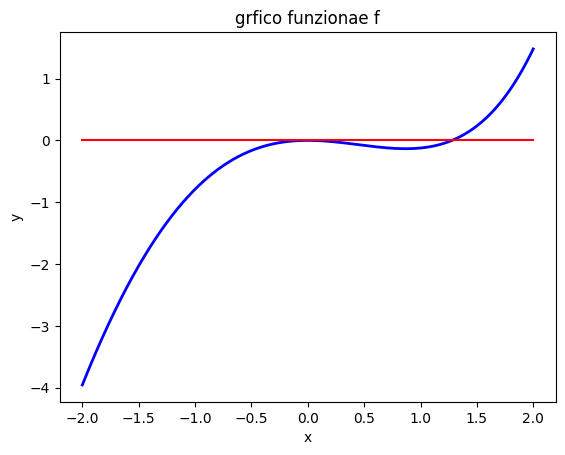

In [14]:
# rappresentazione grafica della funzione f
xgrid = np.linspace(-2,2,1000)
plt.plot(xgrid, f(xgrid),'b-', linewidth=2.0)
plt.plot(xgrid, np.zeros(np.shape(xgrid)), 'r')
plt.title("grfico funzionae f")
plt.xlabel("x")
plt.ylabel("y")

plt.show()

# **Bisezione**


<mark>**Domanda:**</mark></br>
 Il metodo di bisezione è applicabile per calcolare
entrambe le radici? Motivare la risposta.



<mark>**Esercizio 1.1: implementazione bisezione**</mark></br>

Scrivere una function $\verb|bisez|$ che implementi il metodo di bisezione. L'intestazione della funzione sarà ad esempio la seguente:


      def bisez(f,a,b,toll):
      #
      # implementazione di bisezione
      #
      return xvect


Tale funzione riceve in input:
* $\verb|f|→$ funzione di cui vogliamo calcolare gli zeri,
* $a→$ primo estremo
* $b→$ secondo estremo
* $\verb|toll|→$ tolleranza richiesta

e in out
* $\verb|xvect|→$ il vettore delle iterate.




In [141]:
# definzione del metodo di bisezione
def bisez(f, a, b, toll, namx):

  if(f(a)*f(b)>=0):
   raise RuntimeError("ERRORE: A E B NON è UNA BRACKET")
  
  xvect=[]
  for i in range(nmax):
   #for i in range(int((np.ceil(np.log2(abs(b-a)/toll)-1)))):
   print(i)
   #calcolo punto medio
   x=0.5*(a+b)
   if (abs(a-b)<toll):
     break
    
    
    
   if (f(x)==0):
      xvect.append(x)
      print("x è uno zero")
      break


   if (f(x)*f(a)>0):
     a=x
   else:
     b=x
   xvect.append(x)
  
  return np.array(xvect)

bisez(f,1,1.5,1e-10)

TypeError: bisez() missing 1 required positional argument: 'namx'

<mark>**Esercizio 1.2**</mark></br>
Quando è possibile, applicare il metodo di bisezione alla funzione $f$.
Stampare il numero di iterazioni, lo zero trovato $x^*$ e il valore della funzione $f(x^*)$.

In [16]:
# scelta degli estremi a,b
a,b=1, 1.5

xvect = bisez(f, a, b, 1e-12)

x0=xvect[-1]

# stampare il numero di iterazioni effettuato, il valore di x0 e valore di f(x0)
#print("Numero iterazioni: %d." % ???)
      
#print("Ultimo valore di x: %f" % ???)
#print("Ultimo valore di f: %.e\n" % ???)

In [17]:
import numpy as np
import matplotlib.pylab as plt

**Alcuni commenti finali sul metodo di bisezione**

Dalla teoria sappiamo che:

*   Il metodo di bisezione è convergente e abbiamo una stima dell'errore (anche senza dover sapere la soluzione esatta)

\begin{equation}
|e^k| \le \frac{1}{2^{k+1}} |b-a| .
\end{equation}

*   Se voglio ottenere una soluzione esatta a meno di una tolleranza $eps$

\begin{equation}
k > \log_2 \frac{|b-a|}{eps} - 1 .
\end{equation}

*   La convergenza del metodo di bisezione è lenta (l'errore non sempre decresce monotonicamente).

*   Se uno zero ha molteplicità dispari, allora vale il teorema degli zeri. Nel caso di molteplicità pari, non è garantito.

# **Metodo di Newton**

<mark>**Domanda:**</mark></br>
Discutere le proprietà  di convergenza del metodo di Newton per
  entrambi gli zeri, valutando l'opportunità  di applicare il metodo
  di Newton.





<mark>**Esercizio 2.1: implementazione Newton**</mark></br>
Scrivere una function $\verb|newton|$ che implementi il metodo di Newton. L'intestazione della funzione sarà ad esempio la seguente:


      def newton (f,df,x0,nmax,toll)
      #
      # implementazione del metodo di newton
      #
      return xvect

Tale funzione riceve in input:
* $\verb|f|→$ funzione di cui vogliamo calcolare gli zeri,
* $\verb|df|→$ la derivata della funzione $f$,
* $x_0→$ punto di partenza
* $\verb|nmax|→$ numero massimo di iterazione
* $\verb|toll|→$ tolleranza richiesta

e in out
* $\verb|xvect|→$ il vettore delle iterate.

Si utilizzi un criterio d'arresto basato sul modulo della differenza tra due iterate successive.


In [18]:
df = lambda x:  np.exp(x) - 2*x - np.cos(x)

In [19]:
def newtonm(f, df, x0, nmax, toll, m=1):
 xvect=[]
 xold=x0

 for nit in range(nmax):
        if (df(xold)==0):
            raise RuntimeError("errore")
        xnew=xold-m*f(xold)/df(xold)
        xvect.append(xnew)
        if (abs(xnew-xold)<toll):
            break
        else:
            xold=xnew
 return np.array(xvect)
        
xvect= newtonm(f,df, 1.25, 10, 0.0001)
xvect


array([1.28132002, 1.27970578, 1.27970133])

In [20]:
# definizione del metodo di newton
def newton(f, df, x0, nmax, toll):

  # inizializzazione del vettore delle iterazioni
 xvect=[]
 xold=x0
 i=0
  # ciclo iterativo
 while (i<=nmax):
   xnew=xold-f(xold)/df(xold)
   # passo iterativo
   i=i+1
   # carico i vettori
   xvect.append(xnew)
   if (abs(xnew-xold)<toll):
     return np.array(xvect)
   xold=xnew
  
  
  
  
  # criterio di arresto e aggiornamento 

 return np.array(xvect)


xvect= newton(f,df, 1.23, 10, 1e-10)
xvect

array([1.2844812 , 1.27973983, 1.27970133, 1.27970133, 1.27970133])

<mark>**Esercizio 2.3**</mark></br>

Applicare il metodo di Newton e, quando è il caso, il metodo di Newton modificato (aggiungendo la specifica $\verb|m|$) con tolleranza $10^{-6}$, per la funzione
\begin{equation}
f(x):=e^{x}-x^{2}-\textrm{sin}(x)-1,\qquad x\in[-2,2]\;.
\end{equation}
Riportare su un grafico in scala semilogaritmica l'andamento dell'errore in funzione del numero di iterazioni. Per il calcolo dell'errore si assuma come valore esatto dello zero non nullo, il valore $x=1.279701331000996$. Cosa si osserva nell'ordine di convergenza?


In [21]:
# funzione f e la sua derivata df
f = lambda t: np.exp(t) - t**2 - np.sin(t) - 1.0
df = lambda t: np.exp(t) - 2*t - np.cos(t)

[4.12452208e-01 1.47158127e-01 2.73318031e-02 1.19497886e-03
 2.42666061e-06 1.00359721e-11 6.66133815e-16]


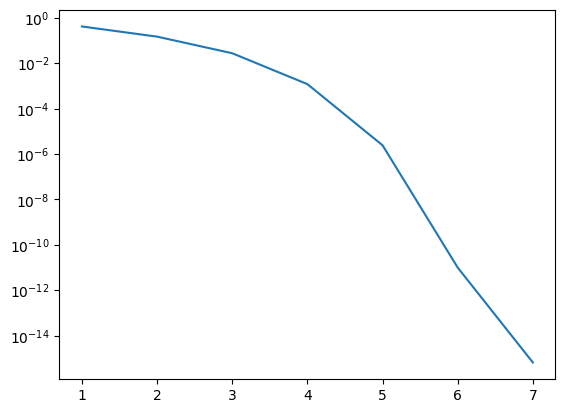

In [22]:
# ricerca dello zero xe=1.279701331000996
xe=1.279701331000996
# starting point
x0=1

xvect = newton(f,df,x0,100,1e-6)
xvect
    
# calcolo dell'errore
error = np.abs(xe-xvect)
error
print(error)
plt.semilogy(np.arange(1,len(xvect)+1),error)
# rappresentazione grafica dell'errore usando plt.semilogy()


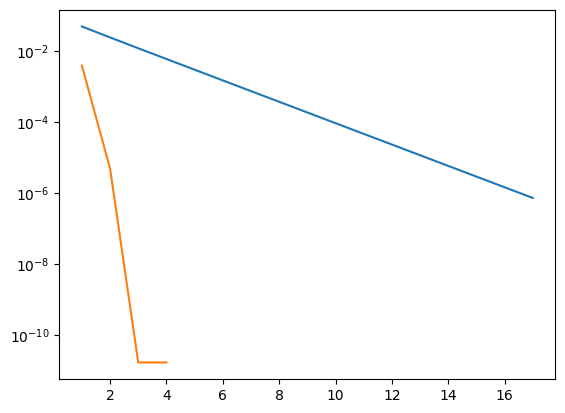

In [23]:
# Ricerca dello zero xe=0
xe=0
# starting point
x0=0.1
xvect = newton(f,df,x0,100,1e-6)
error = abs(xe-xvect)
xvect1 = newtonm(f,df,x0,100,1e-6,2)
error1 = abs(xe-xvect1)
plt.semilogy(np.arange(1,len(xvect)+1), error)
plt.semilogy(np.arange(1,len(xvect1)+1), error1)

**Alcuni commenti finali sul metodo di Newton**

Dalla teoria sappiamo che:

*   Il metodo di Newton è (SOLO) localmente convergente
*   Se converge, allora converge quadraticamente per zeri di molteplicità 1, linearmente per zeri di molteplicità superiore (in tal caso occorre Newton modificato per ripristinare convergenza ottimale)
*   Il metodo di Newton è un particolare metodo di punto fisso

# **Esercizi per casa**


## **Metodo punto fisso**

Si consideri il problema della ricerca degli zeri dell'equazione non lineare $g(x)=0$, dove $g$ è definita da:
\begin{equation}
g(x):= 4x-e^{x^2},\qquad x\in\left[0,\frac{3}{2}\right]\;.
\end{equation}


<mark>**Esercizio 3.1**</mark></br>
Disegnare il grafico della funzione $g$ e la retta $y=0$ in modo
da evidenziare le due soluzioni dell'equazione. Inoltre, per ogni soluzione, determinare un opportuno intervallo che la contenga.

0.26872044315376314


<Figure size 640x480 with 0 Axes>

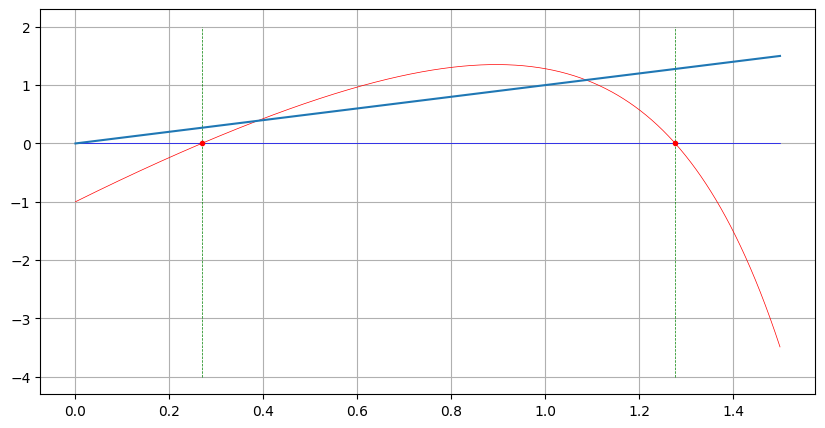

<Figure size 640x480 with 0 Axes>

In [27]:
# plot della funzione g

g=lambda x: 4*x - np.exp(x**2)
dg=lambda x: 4 -np.exp(x**2)*(2*x)
S1=newton(g,dg,0.3,10,1e-10)[-1]
S2=newton(g,dg,1.3,10,1e-10)[-1]
x=np.linspace(0,1.5, 1000)
y=np.linspace(-4,2,1000)
plt.figure(figsize=(10,5))
plt.plot(x,g(x),'-r', linewidth=0.5)
plt.plot(x,(x*0),'b-', linewidth=0.5)
plt.plot(S1*y**0,y,'--g', linewidth=0.5)
plt.plot(S1,0,'.r')
plt.plot(S2*y**0,y,'--g',linewidth=0.5)
plt.plot(S2,0,'.r')
plt.plot(x,x)

plt.grid()

print(S1)
s1=s2=np.linspace(0.2,0.4,1000)
s2=np.linspace(1.2,1.4,1000)
plt.figure()


**Osservazione sulle soluzioni dell'esercizio 3.1:**

In [28]:
newton(g,dg,0.3,10,1e-10)

array([0.26834878, 0.26872039, 0.26872044, 0.26872044])

<mark>**Esercizio 3.2**</mark></br>
Individuare la funzione di iterazione $\phi$ per il metodo di punto fisso e la sua derivata $\phi'(x)$. Plottare $\phi'$ nell'intervallo considerato. Il metodo di punto fisso è applicabile per calcolare
entrambe le radici? Motivare la risposta.

non avevo capito un cazzo, comunque se mettiamo g(x)=0 e isoliamo la x arriviamo nella forma x=phi(x), ma si può isolare la x anche dell'esponenziale??

/tmp/ipykernel_59753/3944443773.py:5: RuntimeWarning: divide by zero encountered in log
  dz= lambda x: (2*np.sqrt(np.log(4*x))*x)**(-1)
/tmp/ipykernel_59753/3944443773.py:5: RuntimeWarning: invalid value encountered in sqrt
  dz= lambda x: (2*np.sqrt(np.log(4*x))*x)**(-1)


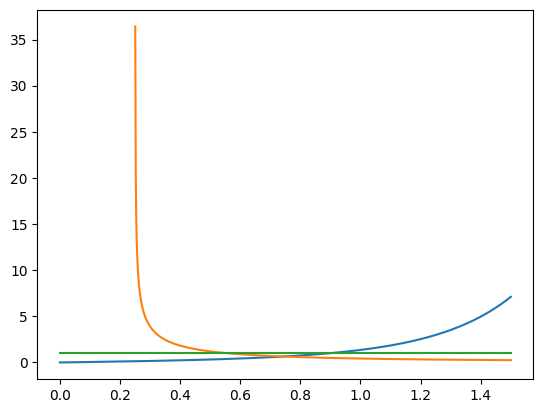

In [62]:
# plot della derivata prima di phi
phi = lambda x: np.exp(x**2)/4
dphi=lambda x: np.exp(x**2)*2*x/4
z=lambda x: np.sqrt(np.log(4*x))
dz= lambda x: (2*np.sqrt(np.log(4*x))*x)**(-1)

plt.plot(x,dphi(x))
plt.plot(x,dz(x))
plt.plot(x,x**0)




**Motivazione esercizio 3.2:**

<mark>**Esercizio 3.3**</mark></br>

Scrivere la function $\verb|puntofisso|$ che implementi il metodo di punto fisso. L'intestazione della funzione sarà ad esempio la seguente:


      def puntofisso (phi,x0,nmax,toll)
        #
        # implementazione del metodo di newton
        #
        return xvect

Tale funzione riceve in input:
* $\verb|phi|→$ funzione di iterazione,
* $x_0→$ punto di partenza
* $\verb|nmax|→$ numero massimo di iterazione
* $\verb|toll|→$ tolleranza richiesta

e in out
* $\verb|xvect|→$ il vettore delle iterate.

Si utilizzi un criterio d'arresto basato sul modulo della differenza tra due iterate successive.

In [67]:
def puntofisso(phi, x0, nmax, toll):
  xold=x0
  xvect=[]
  
  for i in range(nmax):
    
   # if (xold>0.8):
   #   raise RuntimeError("porcodddio la derivarta è maggiore di 1")
    xnew=phi(xold)
    if(abs(xnew-xold)<toll):
      print("dio caner")
      break 
  
    xvect.append(xnew)
    xold=xnew

  return np.array(xvect)

xvect = puntofisso(phi,0.6,10,1e-10)
print(xvect)

S1
S2

[0.35833235 0.28425252 0.27103837 0.26905686 0.26876906 0.26872747
 0.26872146 0.26872059 0.26872046 0.26872045]


np.float64(1.277044573336516)

<mark>**Esercizio 3.3**</mark></br>
Applicare il metodo del punto fisso, quando possibile, con numero massimo di iterazioni $\verb|nmax|=100$ e tolleranza pari a
$10^{-5}$, utilizzando la funzione $\verb|puntofisso|$ e dati iniziali $x0=0$, $x0=1.5$.

In [79]:
sol1 = puntofisso(phi,0,100,1e-5)
print(sol1[-1])
sol2 = puntofisso (z, 1.5,100,1e-10)
print (sol2[-1])

S2

dio caner
0.2687126710670697
dio caner
1.2770445734465041


np.float64(1.277044573336516)

## **Bisezione**

<mark>**Esercizio 4.1**</mark></br>
Si consideri il problema della ricerca degli zeri dell'equazione non
lineare $f(x)=0$, dove $f$ è definita da:
\begin{equation}
f(x):=e^{x}-x^{2}-\textrm{sin}(x)-1,\qquad x\in[-2,2]\;.
\end{equation}

Provare ad implementare bisezione con il ciclo for. Ricordo che il numero massimo di iterazioni è
\begin{equation}
 k > \log_2(\frac{|b-a|}{\text{toll}}) -1
\end{equation}
con $k$ un numero intero. Ricordo che nel caso in cui si ottenga un numero non intero nell'espressione a destra allora $k$ va arrotondato al numero intero superiore. Un comando utile per il calcolo di $k$ è $\verb|np.fix|$ (si veda $\verb|help(np.fix)|$).



In [100]:
#help(np.fix)
np.ceil(2.3)
toll=1e-10
(np.ceil(np.log2(abs(b-a)/toll)-1))
int((np.ceil(np.log2(abs(b-a)/toll)-1)))
 #range(int((np.ceil(np.log2(abs(b-a)/toll)-1))))

32

In [107]:
def bisezfor(f, a, b, toll):
  for i in range(int((np.ceil(np.log2(abs(b-a)/toll)-1)))):
    print(i)
  return

bisezfor(f,a,b,toll)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31


<mark>**Esercizio 4.2**</mark></br>
Testare la function $\verb|bisezfor|$ nella ricerca degli zeri della funzione $f$.

In [ ]:
f = lambda x: np.exp(x) - x**2 - np.sin(x) - 1.0
# scelta degli estremi a,b


# stampare iterazioni, valore di x* e valore di f(x*)



## **Bisezione e Newton**
<mark>**Esercizio 5**</mark></br>
Si consideri il problema della ricerca degli zeri dell'equazione non
lineare $f(x)=0$, dove $f$ è definita da:
\begin{equation}
f(x):=e^{x}-x^{2}-\textrm{sin}(x)-1,\qquad x\in[-2,2]\;.
\end{equation}
Utilizzare in sequenza il metodo di bisezione e il metodo di Newton per la ricerca dello zero $1 < \alpha_2 < 1.5$; in particolare si adotti il metodo di bisezione per l'avvicinamento allo zero e successivamente il metodo di Newton per la
convergenza "veloce" ad $\alpha_2$, assumendo come punto di innesco lo zero approssimato con il metodo di bisezione. Nello specifico si considerino 5 iterazioni del metodo di bisezione sull'intervallo $[1, 1.5]$ e si assuma come tolleranza per il metodo di Newton il valore $10^{-10}$.



In [139]:
# estremi dell'intervallo
a=1
b=1.5
f = lambda x: np.exp(x) - x**2 - np.sin(x) - 1.0
df = lambda x: np.exp(x) - 2*x - np.cos(x)

x0=bisez(f,a,b,1e-10)[-1]
print(x0)
alfa=newton(f,df,x0,5,1e-10)
print(alfa)


0
1
2
3
4
1.265625
[1.2800508  1.27970154 1.27970133 1.27970133]
